In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
print(os.getcwd())


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from load_data import load_images, load_labels

import tensorflow as tf
from tensorflow import keras
print(tf.__version__)

c:\Users\0404l\Documents\GitHub\MNIST-project-DT4031\NN
2.20.0


In [2]:
model = tf.keras.models.load_model("mnist_model_modified2_data.keras")

#Load test data 
# Load test data
X_test = load_images("../MNIST_dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte")
y_test = load_labels("../MNIST_dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte")

num_classes = 10

# ---------------------------
# PREPROCESS TEST DATA
# ---------------------------

# Scale
X_test = X_test.astype("float32") / 255.0

# Add channel dimension (IMPORTANT)
if len(X_test.shape) == 3:
    X_test = np.expand_dims(X_test, -1)

# Keep original labels for per-digit accuracy
y_test_labels = y_test.copy()

# One-hot encode (NO label smoothing!)
y_test = keras.utils.to_categorical(y_test, num_classes=num_classes)

# ---------------------------
# EVALUATE MODEL
# ---------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy on unseen test set: {test_accuracy:.4f}")

# ---------------------------
# PREDICTIONS
# ---------------------------
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# ---------------------------
# PER-DIGIT ACCURACY
# ---------------------------
per_digit_accuracy = {}

for digit in range(10):
    digit_indices = np.where(y_test_labels == digit)[0]

    digit_true = y_test_labels[digit_indices]
    digit_pred = y_pred_classes[digit_indices]

    acc = accuracy_score(digit_true, digit_pred)
    per_digit_accuracy[digit] = acc

    print(f"Digit {digit}: Accuracy = {acc:.4f}")

Final Test Accuracy on unseen test set: 0.9829
Digit 0: Accuracy = 0.9918
Digit 1: Accuracy = 0.9947
Digit 2: Accuracy = 0.9797
Digit 3: Accuracy = 0.9851
Digit 4: Accuracy = 0.9847
Digit 5: Accuracy = 0.9854
Digit 6: Accuracy = 0.9864
Digit 7: Accuracy = 0.9815
Digit 8: Accuracy = 0.9754
Digit 9: Accuracy = 0.9633


In [3]:
# !pip install ipycanvas

In [ ]:
import numpy as np
from ipycanvas import Canvas
from ipywidgets import Layout, Button, VBox, Output
from IPython.display import display, HTML
import time

canvas_size = 28

canvas = Canvas(
    width=canvas_size,
    height=canvas_size,
    sync_image_data=True,
    layout=Layout(width='300px', height='300px')
)

# Background
canvas.fill_style = "black"
canvas.fill_rect(0, 0, canvas_size, canvas_size)

# Drawing style (FIXED)
canvas.stroke_style = "white"
canvas.line_width = 2 # Line size

drawing = False

def on_mouse_down(x, y):
    global drawing
    drawing = True
    canvas.begin_path()
    canvas.move_to(x, y)

def on_mouse_move(x, y):
    if drawing:
        canvas.line_to(x, y)
        canvas.stroke()

def on_mouse_up(x, y):
    global drawing
    drawing = False

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)


# FIXED IMAGE PREPROCESSING
def get_image():
    img = np.array(canvas.get_image_data(0, 0, canvas_size, canvas_size))

    img = img[:, :, 0]          # grayscale
    img = img.astype("float32") / 255.0

    # Match training shape: (1, 28, 28, 1)
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    img = np.clip(img, 0, 1)

    return img


# PREDICTION
predict_button = Button(description="Predict")
out = Output()


def predict_digit(b):
    with out:
        out.clear_output()

        canvas.flush() 
        time.sleep(0.05)      

        img = get_image()

       # print(f"Pixel sum: {np.sum(img):.0f}")  # DEBUG

        pred = model.predict(img, verbose=0)[0]
        sorted_indices = np.argsort(pred)[::-1]

        print(f"Prediction: {sorted_indices[0]}")
        print(f"Confidence: {pred[sorted_indices[0]] * 100:.2f}%")

        print("All Confidences (sorted):")
        for i in sorted_indices:
            print(f"  Digit {i}: {pred[i] * 100:.2f}%")

predict_button.on_click(predict_digit)

clear_button = Button(description="Clear")

def clear_canvas(b):
    canvas.clear()
    canvas.fill_style = "black"
    canvas.fill_rect(0, 0, canvas_size, canvas_size)

clear_button.on_click(clear_canvas)

display(HTML("""
<style>
canvas {
    image-rendering: pixelated !important;
}
</style>
"""))

display(VBox([canvas, predict_button, clear_button, out]))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.99      0.98       892
           6       0.98      0.99      0.99       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.99      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



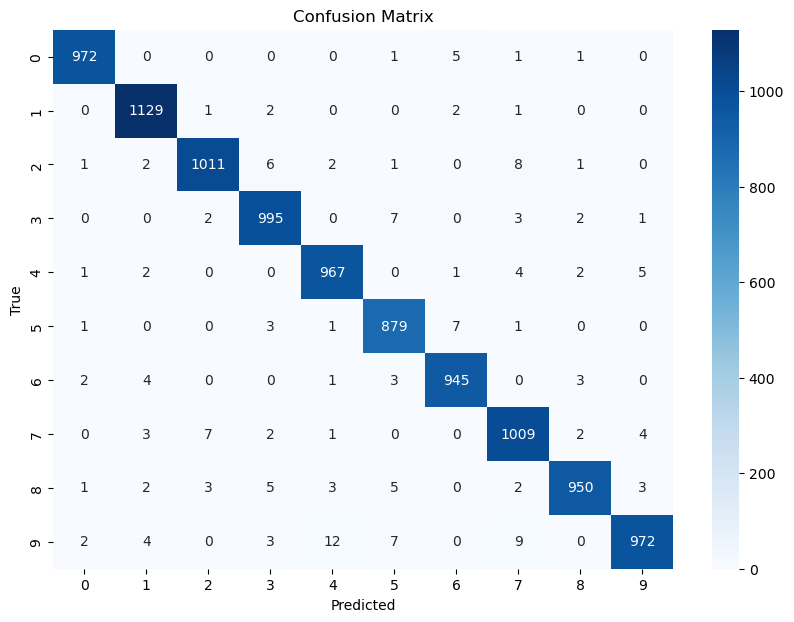

In [5]:
#Confusion matrix and classification report
print("Classification Report:")
print(classification_report(y_test_labels, y_pred_classes))

import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test_labels, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()